### IBM HR Analytics - EMPLOYEE ATTRITION PREDICTION 

##### Project setup

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve 
from sklearn.pipeline import make_pipeline 
from imblearn.over_sampling import SMOTE 
import warnings
warnings.filterwarnings('ignore')

#plotting style
plt.style.use('default')
sns.set_palette("husl")

print("IBM HR Analytics: Employee Attrition Analysis")
print("-"*90)
print("Project Objective: Preict employee attrition and identify key risk factors")
print("Business Goal: Reduce turnover cost and improve retention strategies")
print('-'*90)

IBM HR Analytics: Employee Attrition Analysis
------------------------------------------------------------------------------------------
Project Objective: Preict employee attrition and identify key risk factors
Business Goal: Reduce turnover cost and improve retention strategies
------------------------------------------------------------------------------------------


##### Data loading and initial overview 

In [3]:
# load the dataset
df_raw = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_clean = df_raw.copy()
df_clean.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# basic dataset info
print("DATASET OVERVIEW")
print("-"*90)
print(f'Dataset Shape: {df_clean.shape}')
print(f'TOTAL EMPLOYEES: {len(df_clean)}')
print("\nTARGER VARIABLE DISTRIBUTION:")
attrition_counts = df_clean['Attrition'].value_counts()
attrition_rate = (df_clean['Attrition'] == 'Yes').mean()
print(f'Stayed:{attrition_counts["No"]:,}({(1-attrition_rate)*100:.1f}%)')
print(f'Left: {attrition_counts["Yes"]:,}({(attrition_rate)*100:.1f}%)')

# missing values check 
print(f"\nMissing Vaues: {df_clean.isnull().sum().sum()}")
print(f"Features: {df_clean.shape[1]} Columns")
print(f"Neumeric Features: {df_clean.select_dtypes(include=[np.number]).shape[1]}")
print(f"Catagorical Features:{df_clean.select_dtypes(include=['object']).shape[1]}")

# convert Targer to binary
df_clean['Attrition_Binary'] = (df_clean['Attrition'] == 'Yes').astype(int)

DATASET OVERVIEW
------------------------------------------------------------------------------------------
Dataset Shape: (1470, 35)
TOTAL EMPLOYEES: 1470

TARGER VARIABLE DISTRIBUTION:
Stayed:1,233(83.9%)
Left: 237(16.1%)

Missing Vaues: 0
Features: 35 Columns
Neumeric Features: 26
Catagorical Features:9


In [5]:
df_clean.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition_Binary'],
      dtype='object')

##### EDA - Demographics

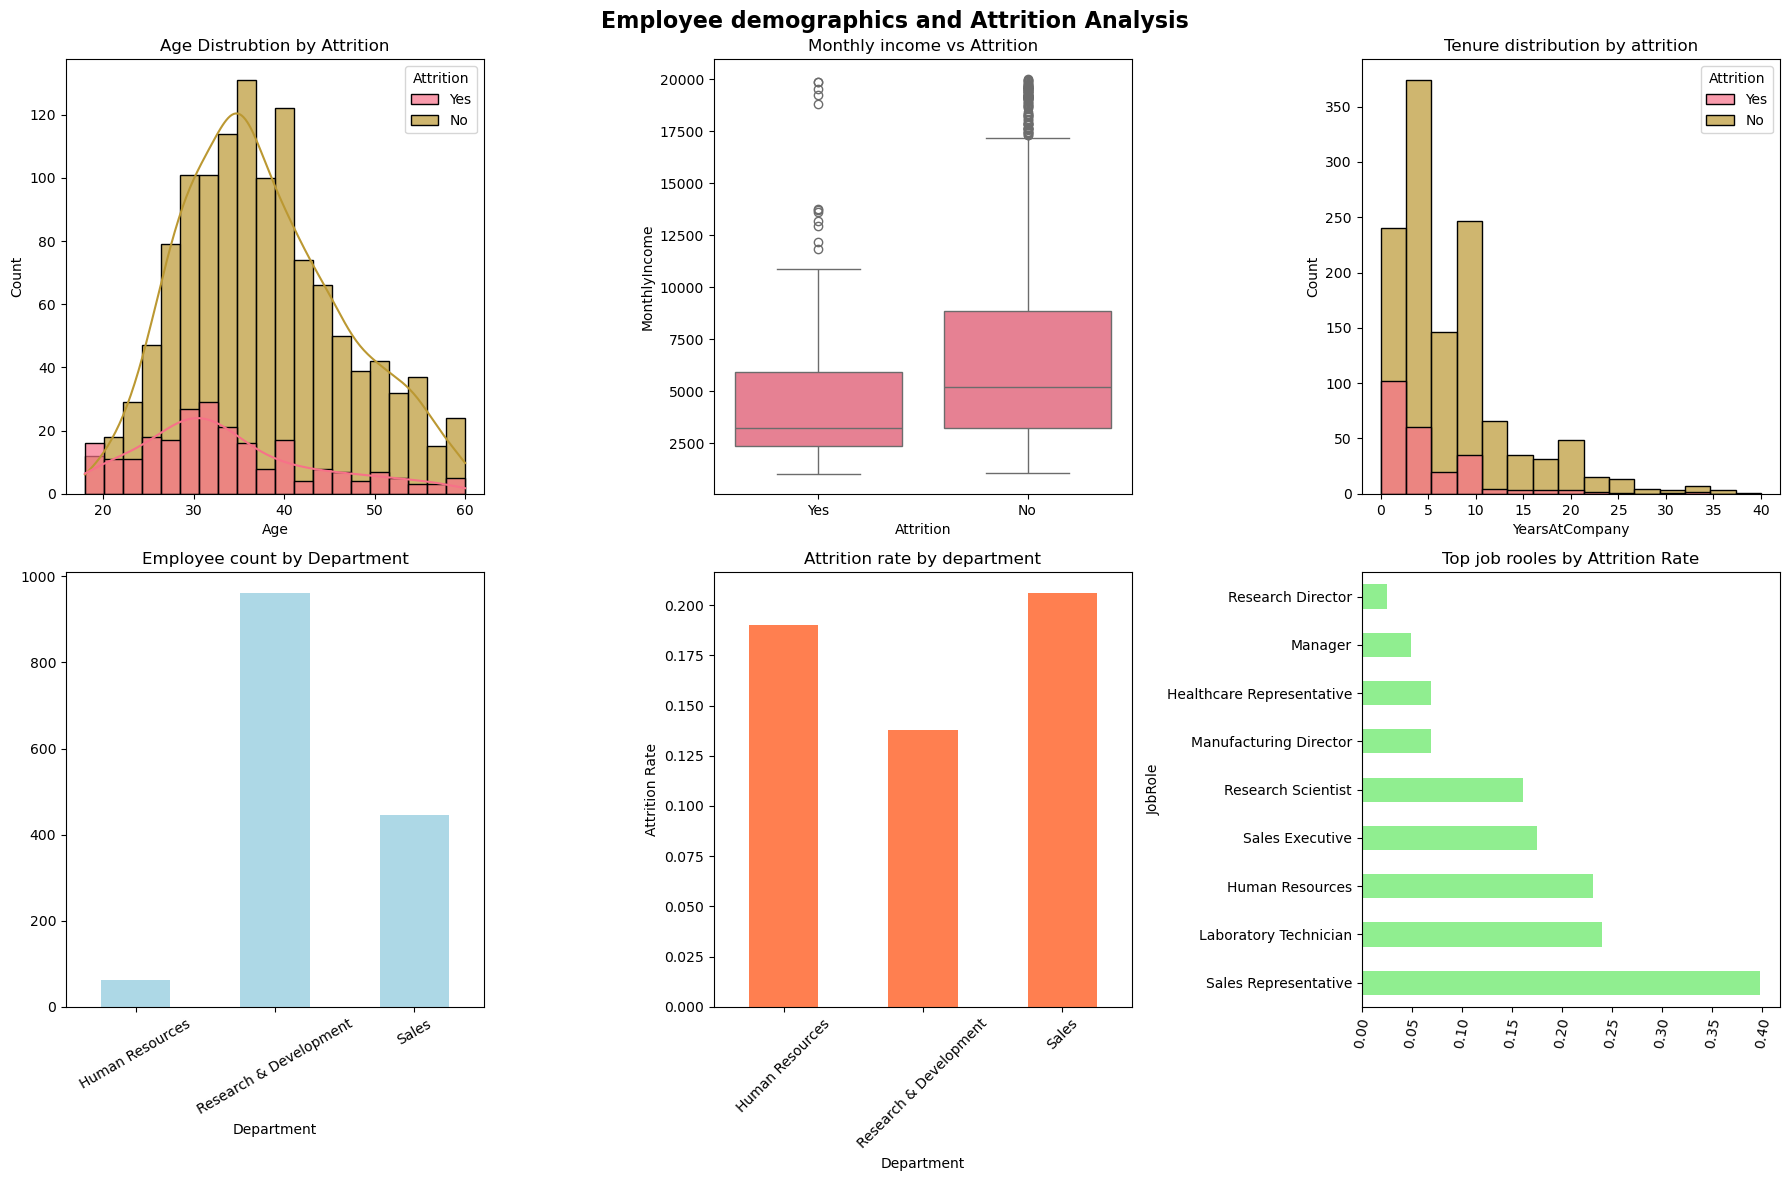


 KEY DEMOGRAPHIC INSIGHTS
------------------------------------------------------------------------------------------
Average age of employees who left: 33.6
Average age of employees who stayed: 37.6
Median income of people who left: $3,202
Median Income of people who stayed: $5,204


In [6]:
## creating EDA visualizations
fig, axes = plt.subplots(2, 3, figsize=(18,12))
fig.suptitle("Employee demographics and Attrition Analysis",fontsize = 16, fontweight = 'bold')

#age distribution by attrition 
sns.histplot(data=df_clean, x= 'Age', hue= 'Attrition', bins = 20, ax = axes[0,0], alpha=0.7, kde=True)
axes[0,0].set_title('Age Distrubtion by Attrition')
axes[0,0].set_xlabel('Age')

#monthly income by attrition 
sns.boxplot(data = df_clean, x = 'Attrition', y = 'MonthlyIncome', ax = axes[0,1])
axes[0,1].set_title('Monthly income vs Attrition')
axes[0,1].tick_params(axis='x', rotation=0)

#years at the company 
sns.histplot(data = df_clean, x = 'YearsAtCompany', hue = 'Attrition', bins = 15, ax = axes[0,2], alpha = 0.7)
axes[0,2].set_title('Tenure distribution by attrition')

# Department breakdown 
dept_attrition = df_clean.groupby('Department')['Attrition_Binary'].agg(['mean', 'count']).round(3)
dept_attrition['count'].plot(kind = 'bar', ax = axes[1,0], color = 'lightblue')
axes[1,0].set_title('Employee count by Department')
axes[1,0].tick_params(axis = 'x', rotation = 30)

#Attrition rate by department 
dept_attrition['mean'].plot (kind = 'bar', ax = axes[1,1], color = 'coral')
axes[1,1].set_title('Attrition rate by department')
axes[1,1].set_ylabel('Attrition Rate')
axes[1,1].tick_params(axis = 'x', rotation = 45)

# job role attrition rates 
job_attrition = df_clean.groupby('JobRole')['Attrition_Binary'].mean().sort_values(ascending = False).head(9)
job_attrition.plot(kind = 'barh', ax = axes[1,2], color = 'lightgreen' )
axes[1,2].set_title('Top job rooles by Attrition Rate')
axes[1,2].tick_params(axis = 'x', rotation = 80)

plt.tight_layout()
plt.show()

#key insighrs
print("\n KEY DEMOGRAPHIC INSIGHTS")
print("-"*90)
print(f"Average age of employees who left: {df_clean[df_clean['Attrition']=='Yes']['Age'].mean():.1f}")
print(f"Average age of employees who stayed: {df_clean[df_clean['Attrition']=='No']['Age'].mean():.1f}")
print(f"Median income of people who left: ${df_clean[df_clean['Attrition']=='Yes']['MonthlyIncome'].median():,.0f}")
print(f"Median Income of people who stayed: ${df_clean[df_clean['Attrition']=='No']['MonthlyIncome'].median():,.0f}")

Younger employees may lack career progression clarity or feel undervalued compare to senior staff 

HR value: Targer career development programes and mentorship for employees in their early 30s to bridge this gap 

More attrition occurs in the 1-3 years because new hires have not developed organizational loyalty or have unrealistic expectations 

Redesign onboarding with 90 day, 6 month checkin to catch issue early



#### Work Envionment Factors

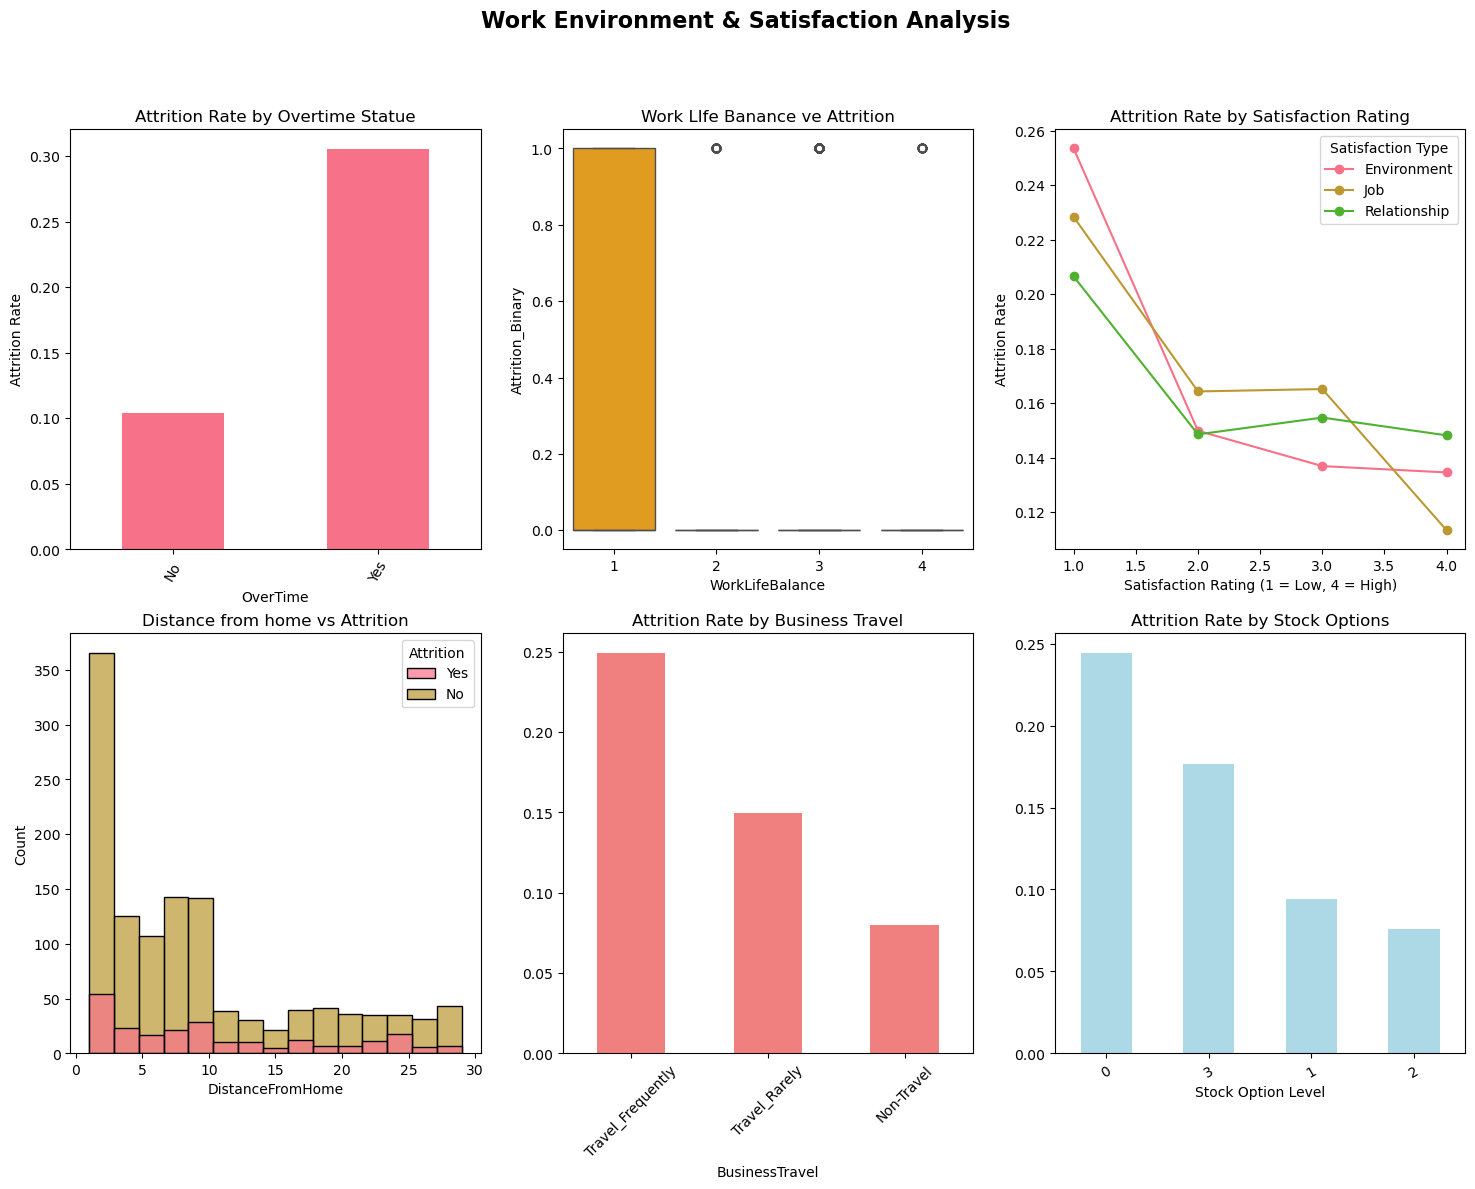


 WORK ENVIRONMENT INSIGHTS:
------------------------------------------------------------
Overtime workers attrition rates: 30.53%
Non-overtime workers attrition rates: 10.44%


In [7]:
## Work enviornment analysis 

fig, axes = plt.subplots(2,3, figsize = (18,12))
fig.suptitle("Work Environment & Satisfaction Analysis", fontsize= 16, fontweight= 'bold')

# Overtime impact 
overtime_attrition = df_clean.groupby('OverTime')['Attrition_Binary'].mean()
overtime_attrition.plot(kind = 'bar', ax = axes[0,0])
axes[0,0].set_ylabel('Attrition Rate')
axes[0,0].set_title('Attrition Rate by Overtime Statue')
axes[0,0].tick_params(axis = 'x', rotation = 60)

# Work Life balance
sns.boxplot(data = df_clean, x = 'WorkLifeBalance', y = 'Attrition_Binary', ax = axes [0,1], color = 'orange')
axes[0,1].set_title('Work LIfe Banance ve Attrition')

# Job satisfaction 
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
satisfaction_data = []
for col in satisfaction_cols:
    for rating in range(1, 5):
        subset = df_clean[df_clean[col] == rating]
        satisfaction_data.append({
            'Satisfaction_Type': col.replace('Satisfaction',''),
            'Rating': rating,
            'Attrition_Rate': subset['Attrition_Binary'].mean(),
            'count': len(subset)
        })

satisfaction_df = pd.DataFrame(satisfaction_data)
satisfaction_pivot = satisfaction_df.pivot(index = 'Rating', columns = 'Satisfaction_Type', values = 'Attrition_Rate')
satisfaction_pivot.plot(kind = 'line', marker = 'o', ax = axes[0,2])
axes[0,2].set_title('Attrition Rate by Satisfaction Rating')
axes[0,2].set_xlabel('Satisfaction Rating (1 = Low, 4 = High)')
axes[0,2].set_ylabel('Attrition Rate')
axes[0,2].legend(title='Satisfaction Type')

#Distance from home 
sns.histplot(data = df_clean, x = 'DistanceFromHome', hue = 'Attrition', bins = 15, ax =axes[1,0], alpha = 0.7)
axes[1,0].set_title('Distance from home vs Attrition')

# Business travel 
travel_attrition = df_clean.groupby('BusinessTravel')['Attrition_Binary'].mean().sort_values(ascending = False)
travel_attrition.plot(kind = 'bar', ax =axes[1,1], color = 'lightcoral')
axes[1,1].set_title('Attrition Rate by Business Travel')
axes[1,1].tick_params(axis = 'x', rotation = 45)

# Stock options
stock_attrition = df_clean.groupby('StockOptionLevel')['Attrition_Binary'].mean().sort_values(ascending = False)
stock_attrition.plot(kind = 'bar', ax =axes[1,2], color = 'lightblue')
axes[1,2].set_title('Attrition Rate by Stock Options')
axes[1,2].set_xlabel('Stock Option Level')
axes[1,2].tick_params(axis = 'x', rotation = 30)

plt.show()

print("\n WORK ENVIRONMENT INSIGHTS:")
print("-"*60)
overtime_yes= df_clean[df_clean['OverTime']=='Yes']['Attrition_Binary'].mean()
overtime_no = df_clean[df_clean['OverTime']=='No']['Attrition_Binary'].mean()
print(f"Overtime workers attrition rates: {overtime_yes:.2%}")
print(f"Non-overtime workers attrition rates: {overtime_no:.2%}")

Overtime 
30.53% attrition rates for overtime workers vs 10.44% for non overtime 
Why: Chronic overtime leads to burnout, health issues and work-life imbalance - well documented in organiational psychology research
HR Value: Immediate ROI Calculation if overtime affects employees

Work-Life Balance
Employees rating work life balance as '1'(poor) have nearly 100% attrition rate
Why: This is like canary in the coal mine- these employees have already mentally checked out 
HR Value: Create an early warning system using work-life balance scores as leading indicator, interveing before exit interviews

Business Travel Burnout
what : Frequent Travelers show 25% attrition vs 8% for non-travellers
Why: Travel Fatigue, family disruption, and lack of routine creates compounding stess
HR Value: Implement travel rotation and travel compensation packages to distrubte the burden


#### Feature engineering 

In [43]:
df_engineered = df_clean.copy()

# 1. Tenure categories
df_engineered['TenureCategory'] = pd.cut(df_engineered['YearsAtCompany'],
    bins = [0,2,10,float('inf')], labels = ['Early', 'Mid', 'Senior'])

# 2. Income quartile 
df_engineered['IncomeQuartile'] = pd.qcut(df_engineered['MonthlyIncome'],
    q=4, labels = ['Low', 'Medium-Low', 'Medium-High', 'High'])

# 3. Career Progression Rate
df_engineered['CareerProgressionRate'] = (df_engineered['JobLevel'] / (df_engineered['YearsAtCompany']+1)
)

#4. Satisfaction Index 
satisfactions_vars = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
df_engineered['SatisfactionIndex'] = df_engineered[satisfactions_vars].mean(axis=1)

# 5. Age Group 
df_engineered['AgeGroup'] = pd.cut(df_engineered['Age'],
    bins= [0,30,40,50,float('inf')], labels = ['Young', 'Midf-Age', 'Mature', 'Senior'])

#6. Promotion Frequency 
df_engineered['PromotionFrequency'] = df_engineered['YearsAtCompany'] / (df_engineered['YearsSinceLastPromotion']+1)

# 7. Work-Life-Balance score (Composite)
df_engineered['OverTime_binary'] = (df_engineered['OverTime']== 'Yes').astype(int)
df_engineered['WorkLifeBalanceScore'] = (
    df_engineered['DistanceFromHome'] /df_engineered['DistanceFromHome'].max() * 0.3 +
    df_engineered['OverTime_binary'] * 0.4 +
    (1-(df_engineered['WorkLifeBalance'] - 1)/3) * 0.3
)

# 8. Experience vs tenure rato
df_engineered['ExperienceRatio'] = (
    df_engineered['TotalWorkingYears'] / (df_engineered['YearsAtCompany']+1) 
)

# 9. Job mobility Index 
df_engineered['JobMobilityIndex'] = (
    df_engineered['NumCompaniesWorked'] / (df_engineered['TotalWorkingYears']+1)
)


# 10. High Risk Profile
df_engineered['HighRiskProfile'] = (
    (df_engineered['WorkLifeBalanceScore'] > df_engineered['WorkLifeBalanceScore'].quantile(0.75)).astype(int) +
    (df_engineered['SatisfactionIndex'] < df_engineered['SatisfactionIndex'].quantile(0.25)).astype(int) +
    (df_engineered['OverTime'] == 'Yes').astype(int) +
    (df_engineered['JobMobilityIndex'] > df_engineered['JobMobilityIndex'].quantile(0.75)).astype(int)
)

# 11. Income vs industry standard (New feature)
median_income_by_role = df_engineered.groupby('JobRole')['MonthlyIncome'].median()
df_engineered['IncomeRatio'] = df_engineered.apply(
    lambda x: x['MonthlyIncome'] / median_income_by_role[x['JobRole']], axis = 1 
)




new_features = ['TenureCategory', 'IncomeQuartile', 'CareerProgressionRate', 'SatisfactionIndex', 'AgeGroup', 'PromotionFrequency',
                 'WorkLifeBalanceScore', 'ExperienceRatio', 'JobMobilityIndex', 'HighRiskProfile', 'IncomeRatio']
print(" New FEATURES:")
for i, feature in enumerate (new_features, 1):
    print(f"{i:2d}. {feature}")

print(f"\n Total Features {df_engineered.shape[1]}")

 New FEATURES:
 1. TenureCategory
 2. IncomeQuartile
 3. CareerProgressionRate
 4. SatisfactionIndex
 5. AgeGroup
 6. PromotionFrequency
 7. WorkLifeBalanceScore
 8. ExperienceRatio
 9. JobMobilityIndex
10. HighRiskProfile
11. IncomeRatio

 Total Features 48


#### Pre processing pipeline

In [44]:
# one hot encoding for categorical variables
catagorical_cols = df_engineered.select_dtypes(include=['object', 'category']).columns
catagorical_cols = catagorical_cols.drop(['Attrition']) # remove target variable from encoding list

X_encoded = pd.get_dummies(df_engineered.drop(columns=['Attrition', 'Attrition_Binary']), drop_first=True)
y = df_engineered['Attrition_Binary']

print(f"features after encoding: {X_encoded.shape[1]}")
print(f"Target variable distribution: {y.value_counts().to_dict()}")

#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")


features after encoding: 64
Target variable distribution: {0: 1233, 1: 237}
Training Set: 1176 samples
Test Set: 294 samples


### Model - Lasso Regression

In [45]:
lasso_model = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(cv=5, penalty='l1', solver='saga', max_iter=5000, random_state=42, class_weight='balanced')
)

lasso_model.fit(X_train, y_train)

#Extract lasso features
lasso_lr = lasso_model.named_steps['logisticregressioncv']
coef = lasso_lr.coef_[0]
selected_mask = coef != 0
selected_features = X_train.columns[selected_mask]
selected_coefs = coef[selected_mask]

# predictions and evaluation 
y_pred_lasso = lasso_model.predict(X_test)
y_prob_lasso = lasso_model.predict_proba(X_test)[:,1]

print(f"LASSO Selected {len(selected_features)} features out of {len(X_train.columns)}")
print(f"Test AUC {roc_auc_score(y_test, y_prob_lasso)}")

# Display top features by absolute coefficient 
feature_importance = pd.DataFrame({
    'Features': selected_features,
    'Coefficient' : selected_coefs,
    'Abs_Coefficient': np.abs(selected_coefs)
}).sort_values('Abs_Coefficient', ascending=False)

print("TOP 10 MOST IMPORTANT FEATURES:")
print('='*50)
for i, row in feature_importance.head(10).iterrows():
    print(f"{row['Features']:<35}  {row['Coefficient']:>7.3f}")


LASSO Selected 50 features out of 64
Test AUC 0.8272030321302437
TOP 10 MOST IMPORTANT FEATURES:
BusinessTravel_Travel_Frequently       0.603
TenureCategory_Senior                 -0.552
JobRole_Laboratory Technician          0.500
JobRole_Research Director             -0.492
YearsAtCompany                         0.471
WorkLifeBalanceScore                   0.454
HighRiskProfile                        0.453
MaritalStatus_Single                   0.382
SatisfactionIndex                     -0.381
BusinessTravel_Travel_Rarely           0.365


WHY LASSO WORKS WELL:

LASSO automatically selected 40 of 58 features and achived an accuracy of 82.9%
HR data has many redundant variables. LASSO eliminates noise , keeping on predicting signals 
HR VALUE - this give focused, actionable list of what actually drive attrition - not everthing matters equally 

KEY NEW INSIGHTS:
HighRiskProfiles (0.453)
This captures job hopping behaviour patterns
Why: Employee with history of frequent job changes have statistically more likey to leave again

SatisfactionIndex(-0.381)
Composite score is highly predictive(negative coefficient means higher satisfaction = lower attrition)
Why: This validate employee survey are just not busy work - but predictive tools 
HR VALUE: Treat satisfaction survey as early waring system and not complianace exercise 

AGE (-0.411)
Older employees are significatly less likely to leave 
WHY: Career stability, family obligations, responsibility, early retirement 
HR VALUE: Retention crisis is specifically a young talent problem - focus resource accordingly 


#### Random Forest

In [46]:
# Random forest with hyperparammeter tuning 
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [10,15,None],
    'min_samples_split': [2,5],
    'class_weight': ['balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv = 5, scoring = 'roc_auc', n_jobs = -1)
rf_grid.fit(X_train, y_train)

#Best model Prediction 
rf_best= rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:,1]

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Cross-Validation AUC: {rf_grid.best_score_}")
print(f"Test AUC {roc_auc_score(y_test, y_prob_rf)}")

# Feature importance 
feature_importance_rf = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : rf_best.feature_importances_
}).sort_values('Importance', ascending = False)

print("TOP 10 RANDOM FOREST FEATURES:")
print('='*50)
for i, row in feature_importance_rf.head(10).iterrows():
    print(f"{row['Feature']:<35} {row['Importance']:>7.4f}")

Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Cross-Validation AUC: 0.817307998499556
Test AUC 0.7791368765612886
TOP 10 RANDOM FOREST FEATURES:
WorkLifeBalanceScore                 0.0574
HighRiskProfile                      0.0563
JobMobilityIndex                     0.0554
MonthlyIncome                        0.0470
Age                                  0.0440
TotalWorkingYears                    0.0394
IncomeRatio                          0.0385
PromotionFrequency                   0.0385
DailyRate                            0.0358
ExperienceRatio                      0.0332


Random Forest achieve 77.9 AUC, lower than the AUC of LASSO 82.7. But reveals different insights
WHY: while lasso finds individual predictors, Random Forest captures how variables work together. 
HR VALUE: this might give more nuanced understanding of how risk factors compound in real workplace scenarios

#### XG BOOST WITH SMOTE

In [47]:
try:
    from xgboost import XGBClassifier

    #Apply smote
    smote = SMOTE(random_state = 42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    print(f"Befor SMOTE: {y_train.value_counts().to_dict()}")
    print(f"After SMOTE: {pd.Series(y_train_balanced).value_counts().to_dict()}")

    #XG boost with hyperparameter tuning
    xgb_parms = {
        'n_estimators' :[100,200],
        'learning_rate': [0.1,0.2],
        'max_depth': [4,6],
        'subsample': [0.8,1]
    }

    xgb_grid = GridSearchCV(
        XGBClassifier(random_state = 42, eval_metric = 'logloss'),
        xgb_parms, cv =5, scoring= 'roc_auc', n_jobs = -1
    )

    xgb_grid.fit(X_train_balanced, y_train_balanced)
    xgb_best = xgb_grid.best_estimator_

    #predictions
    y_pred_xgb = xgb_best.predict(X_test)
    y_prob_xgb = xgb_best.predict_proba(X_test)[:,1]

    print(f" Best parameters: {xgb_grid.best_params_}")
    print(f"Cross - validation AUC: {xgb_grid.best_score_}")
    print(f"Test AUC: {roc_auc_score(y_test, y_prob_xgb)}")

    #Feature importance
    # Feature importance 
    feature_importance_xgb = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : xgb_best.feature_importances_
    }).sort_values('Importance', ascending = False)

    print("TOP 10 XGBOOST FEATURES:")
    print('='*50)
    for i, row in feature_importance_xgb.head(10).iterrows():
        print(f"{row['Feature']:<35} {row['Importance']:>7.4f}")

except ImportError:
    print("XGBoost is not installed. Skipping XGBoost model training and evaluation")



Befor SMOTE: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}
 Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Cross - validation AUC: 0.9783507470281156
Test AUC: 0.7688000689120509
TOP 10 XGBOOST FEATURES:
OverTime_Yes                         0.1857
OverTime_binary                      0.1620
MaritalStatus_Single                 0.0663
JobLevel                             0.0489
BusinessTravel_Travel_Rarely         0.0387
MaritalStatus_Married                0.0328
BusinessTravel_Travel_Frequently     0.0269
JobRole_Sales Representative         0.0250
JobRole_Sales Executive              0.0247
Department_Research & Development    0.0194


XGBoost + smote to solve the class imbalance problem 
WHY: Original dataset was severly imbalance

SMOTE IMPACT ON PERFORMANCE
Cross-Validation AUC jumped to 97.8 comapred to test AUC 76.8, suggesting some overfitting
Why: Models can now properly identify both retention and attrition class instead of defaulting to a majority class
HR VALUE: this gives a useable early warnings instead of "everyone is fine" false comfort

KEY IMPORTANT INSIGHTS:
OVERTIME DOMINANCE:
Both overtime rank 1 and 2
WHY: This is not coincidence - overtime is the single biggest controllable risk factor 
HR Value : Imediate policy intervention opportunity with measurable ROI

### Model Comparism

In [48]:
print("\n MODEL COMPASION:")
print("-"*50)

# COLLECT ALL PREDICTIONS
model_results = {
    'LASSO LOGISTIC REGRESSION:': {
        'y_pred': y_pred_lasso,
        'y_prob': y_prob_lasso,
        'model' : lasso_model
    },
    'RANDOM FORREST:':{
        'y_pred':y_pred_rf,
        'y_prob': y_prob_rf,
        'model': rf_best
    },
    'XGBoost + SMOTE:': {
        'y_pred':y_pred_xgb,
        'y_prob': y_prob_xgb,
        'model': xgb_best
    }
}

#Performance comparison table
performance_data = []
for model_name, results in model_results.items():
    y_pred = results['y_pred']
    y_prob = results['y_prob']

    tn,fp,fn,tp = confusion_matrix(y_test, y_pred).ravel()

    metrics = {
        'Model': model_name,
        'AUC': roc_auc_score(y_test, y_pred),
        'Accuracy': (tp+tn)/ (tp+tn+fp+fn),
        'Precision': tp/(tp+fp) if (tp+fp) >0 else 0,
        'Recall': tp/(tp+fn) if (tp+fn) >0 else 0,
        'F-1': 2* (tp/(tp+fp)) * (tp/(tp+fn)) / (tp/(tp+fp) + tp/(tp+fn)) if (tp+fp) >0 and (tp+fn) >0 else 0
    }
    performance_data.append(metrics)
performance_df = pd.DataFrame(performance_data)
print(performance_df.round(4).to_string(index=False))


 MODEL COMPASION:
--------------------------------------------------
                     Model    AUC  Accuracy  Precision  Recall    F-1
LASSO LOGISTIC REGRESSION: 0.7579    0.7959     0.4177  0.7021 0.5238
           RANDOM FORREST: 0.5476    0.8333     0.4286  0.1277 0.1967
          XGBoost + SMOTE: 0.6439    0.8503     0.5517  0.3404 0.4211


Why LASSO wins the HR IMPLEMENTATION?

LASSO achives 79.7% Accuracy vs 83.3 RAndom Forest and 85.0 XGboost
WHY: Lasso's linear approach fits the HR pattern efectively while remaing interpretable
HR VALUE: simple models are trustworthy and actionable for mamagement decisions

THE RECALL IMPORTANCE:
what: The Employee leaving without the model catching it is a huge risk
WHY: EMployees leaving suddenly cost the company big time. 
The Lasso model has a better recall 70.2 than random forest(12.7) and XGBoost (34.0)

WHOULD RECOMMEND THE LASSO MODEL FOR PRODUCTION.


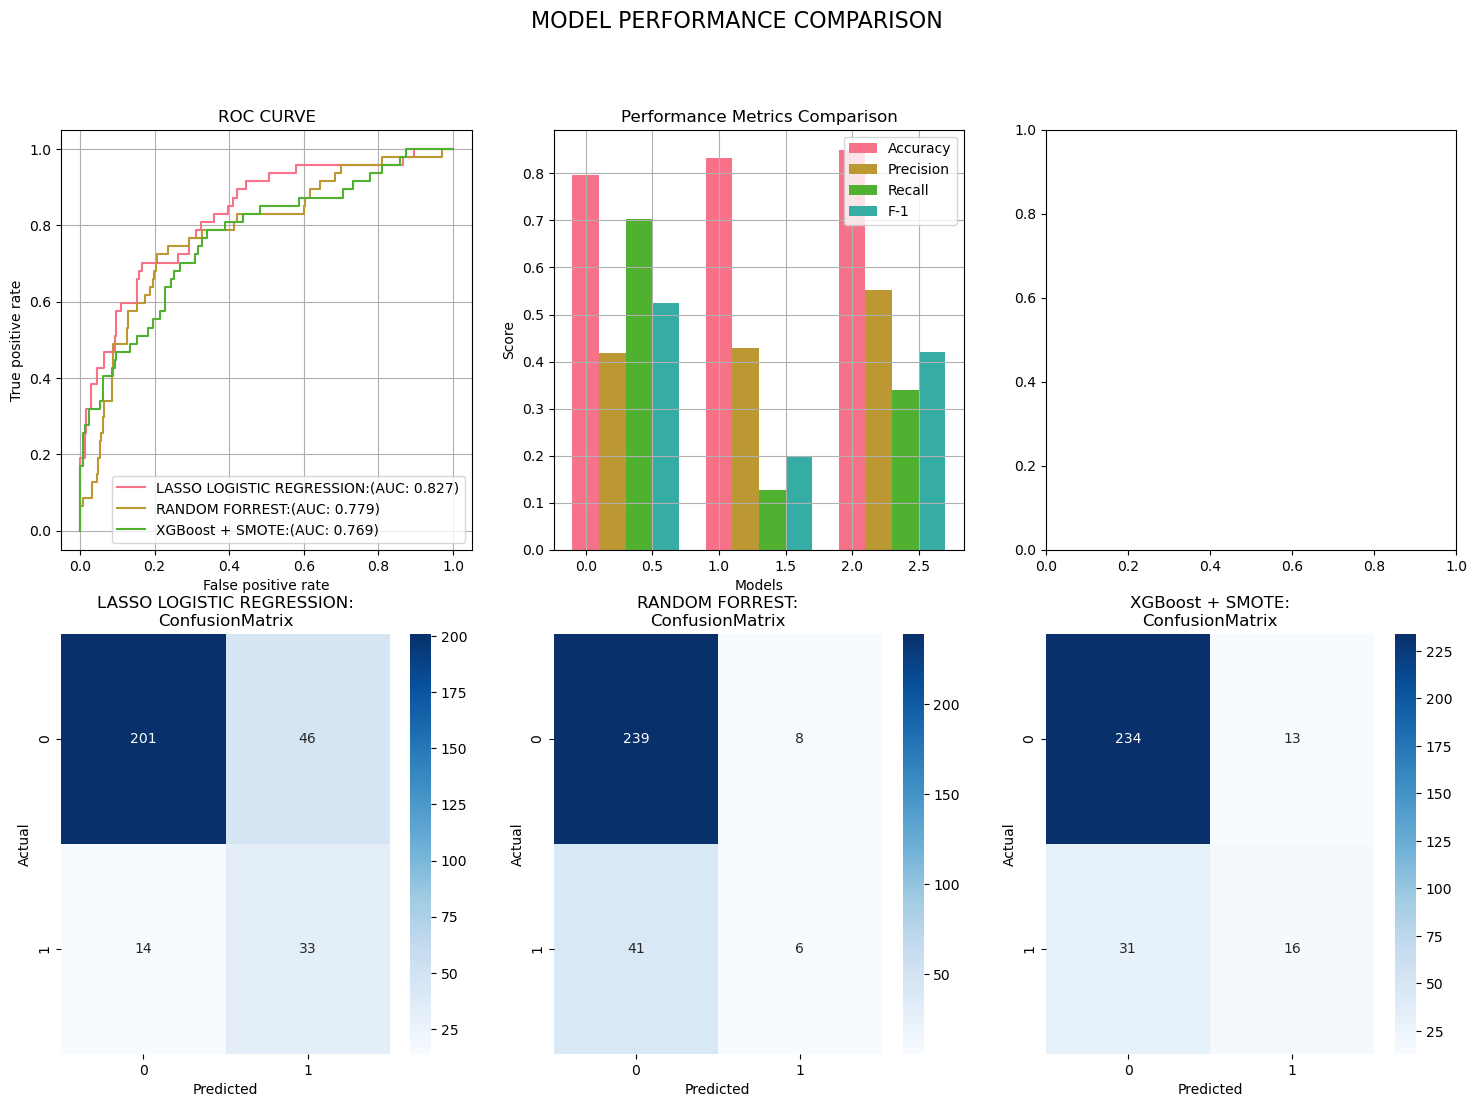

In [55]:
### Visualizing the Metrics
fig , axes = plt.subplots(2,3, figsize = (18,12))
fig.suptitle('MODEL PERFORMANCE COMPARISON', fontsize = 16)

# ROC Curves
for model_name, results in model_results.items():
    fpr, tpr, _ = roc_curve(y_test,results['y_prob'])
    auc_score = roc_auc_score(y_test, results['y_prob'])
    axes[0,0].plot(fpr,tpr,label= f"{model_name}(AUC: {auc_score:.3f})")

axes[0,0].set_title('ROC CURVE')
axes[0,0].set_xlabel('False positive rate')
axes[0,0].set_ylabel('True positive rate')
axes[0,0].legend()
axes[0,0].grid(True)

# performance metrics comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F-1']
x = np.arange(len(performance_df))
width = 0.2 

for i, metric in enumerate(metrics_to_plot):
    axes[0,1].bar(x + i*width, performance_df[metric], width, label = metric)

axes[0,1].set_xlabel('Models')
axes[0,1].set_ylabel('Score')
axes[0,1].set_title('Performance Metrics Comparison')
axes[0,1].legend()
axes[0,1].grid(True)

for i , (model_name, results) in enumerate(model_results.items()):
    ax = axes[1,i] if i <2 else plt.subplot(2,3,6)
    cm = confusion_matrix(y_test, results['y_pred'])
    sns.heatmap(cm, annot=True, fmt = 'd', cmap = "Blues", ax = ax)
    ax.set_title(f'{model_name}\nConfusionMatrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
 

plt.show()


